Start from the dataset kickstarter-14-04, take out the unnecessary columsn that I don't know why are there:

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
from nltk.corpus import stopwords
import string 
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import re 
from collections import Counter
import ast
import glob
from collections import Counter
from scipy import stats

loading the dataset: 

In [2]:
campaigns = pd.read_csv('raw_kickstarter.csv', index_col=0)


adding the columns: 
- 'reached' = the % of the funding goal reached by the campaign
- 'status' = 1 or 0 identifying a campaign as success or failure depending on if it reached 100% of the funding goal or not 
- 'video' = 1 o 0 depending on whether the campaign includes in their page a video or not 
- 'duration' = the duration in days of the campaign, calculated as the time between the deadline and when the campaign was launched 

In [3]:
campaigns['reached'] = (campaigns['pledged'] / campaigns['goal']) * 100

campaigns['status'] = campaigns['reached'].apply(lambda x: 1 if x >= 100 else 0)

campaigns['video']  = campaigns['video'].apply(lambda x: 0 if type(x) == float else 1)

campaigns['duration'] = (pd.to_datetime(campaigns['deadline'], unit ='s') - pd.to_datetime(campaigns['launched_at'], unit = 's')).dt.days

# finally dropping the columns 'launched_at' and 'deadline' since they are not needed anymore 
campaigns = campaigns.drop(columns= ['launched_at', 'deadline']) 

defining the preprocess function, which: 
- lowercases all the words in each description
- takes out possible urls from the description and punctuation and symbols 
- tokenizes the words 
- returns only alphabetic tokens that are not in the pre-loaded stopword list 


In [4]:
stop_words = set(stopwords.words("english"))
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = word_tokenize(text)
    return [token for token in tokens if token.isalnum() and not token.isdigit() and token not in stop_words]

campaigns['description_processed'] = campaigns['description'].apply(preprocess)


In [5]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return 'a'
    if treebank_tag.startswith('V'):
        return 'v'
    if treebank_tag.startswith('N'):
        return 'n'
    if treebank_tag.startswith('R'):
        return 'r'
    return 'n'

# here basically for all tokens you assign POS to get (token, POS) through ntlk
campaigns['pos_tagged'] = campaigns['description_processed'].apply(nltk.pos_tag)


# now here you lemmatize the POS-tagged tokens, meaning if before you had tokens 'run' and 
# 'running' as the couple (token, 'Verb'), now those couple are fed into the lemmatization 
# to get out a single token (run)
campaigns['lemmatized'] = campaigns['pos_tagged'].apply(
    lambda tagged_words: [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in tagged_words
    ]
)


In [6]:

pos_tagged_verbs = [
    word
    for tagged_words in campaigns['pos_tagged']
    for word, pos in tagged_words
    if pos.startswith('VB')
]
pos_tagged_nouns = [
    word
    for tagged_words in campaigns['pos_tagged']
    for word, pos in tagged_words
    if pos.startswith('NN')
]

# 4) Verb/Noun extraction from POS-aware lemmatized tokens
lemma_verbs = [
    lemmatizer.lemmatize(word, 'v')
    for tagged_words in campaigns['pos_tagged']
    for word, pos in tagged_words
    if pos.startswith('VB')
]
lemma_nouns = [
    lemmatizer.lemmatize(word, 'n')
    for tagged_words in campaigns['pos_tagged']
    for word, pos in tagged_words
    if pos.startswith('NN')
]


# Optional unique vocab views
print("\nUnique vocab sizes:")
print(f"Unique POS-tagged verbs: {len(set(pos_tagged_verbs))}")
print(f"Unique POS-tagged nouns: {len(set(pos_tagged_nouns))}")
print(f"Unique lemmatized verbs: {len(set(lemma_verbs))}")
print(f"Unique lemmatized nouns: {len(set(lemma_nouns))}")


Unique vocab sizes:
Unique POS-tagged verbs: 33633
Unique POS-tagged nouns: 64398
Unique lemmatized verbs: 26393
Unique lemmatized nouns: 57462


In [7]:
initial_vocab = set(token for doc in campaigns['lemmatized'] for token in doc)
print(f"lenght of the initial vocabulary: {len(initial_vocab)}")

lenght of the initial vocabulary: 85469


zipf's law demonstration in our dataset:
              word  frequency   rank  cumsum_freq  cumsum_pct
0            make      24805      1        24805    0.609220
1            game      20788      2        45593    1.119780
2            film      20532      3        66125    1.624053
3            work      17740      4        83865    2.059754
4             one      17678      5       101543    2.493932
...           ...        ...    ...          ...         ...
85464         p2v          1  85465      4071599   99.999902
85465    dreading          1  85466      4071600   99.999926
85466  midsection          1  85467      4071601   99.999951
85467   overthink          1  85468      4071602   99.999975
85468     buildng          1  85469      4071603  100.000000

[85469 rows x 5 columns]


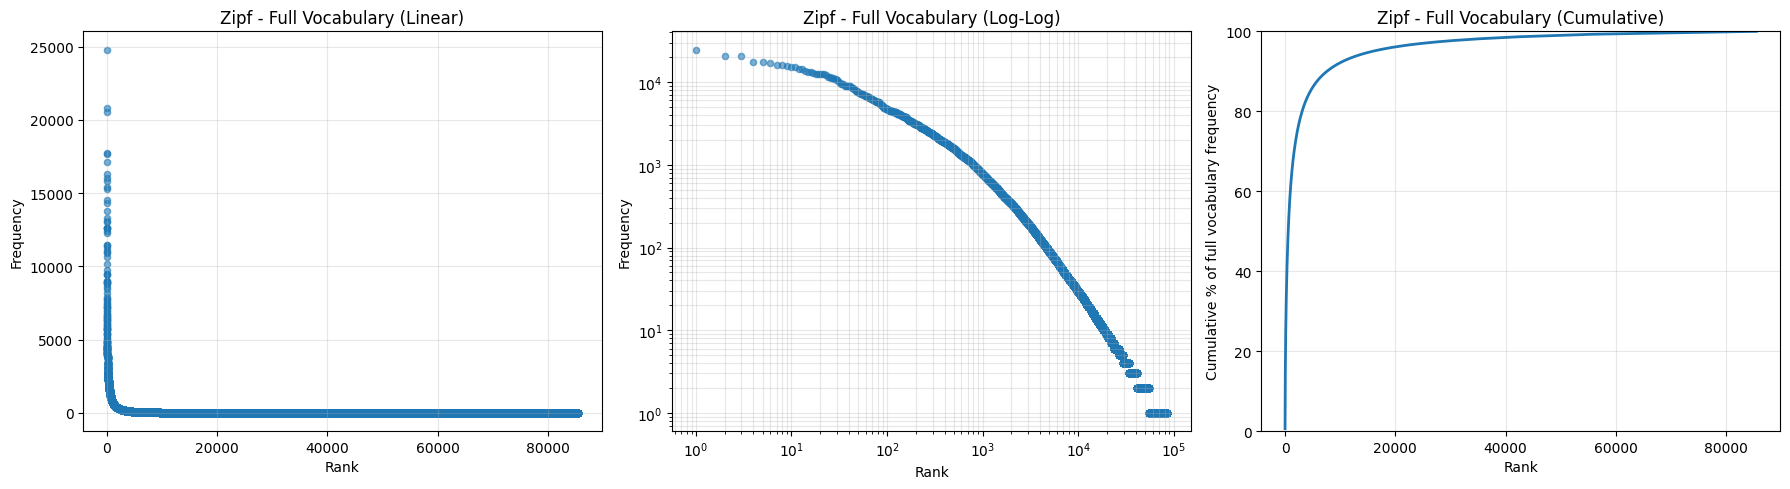

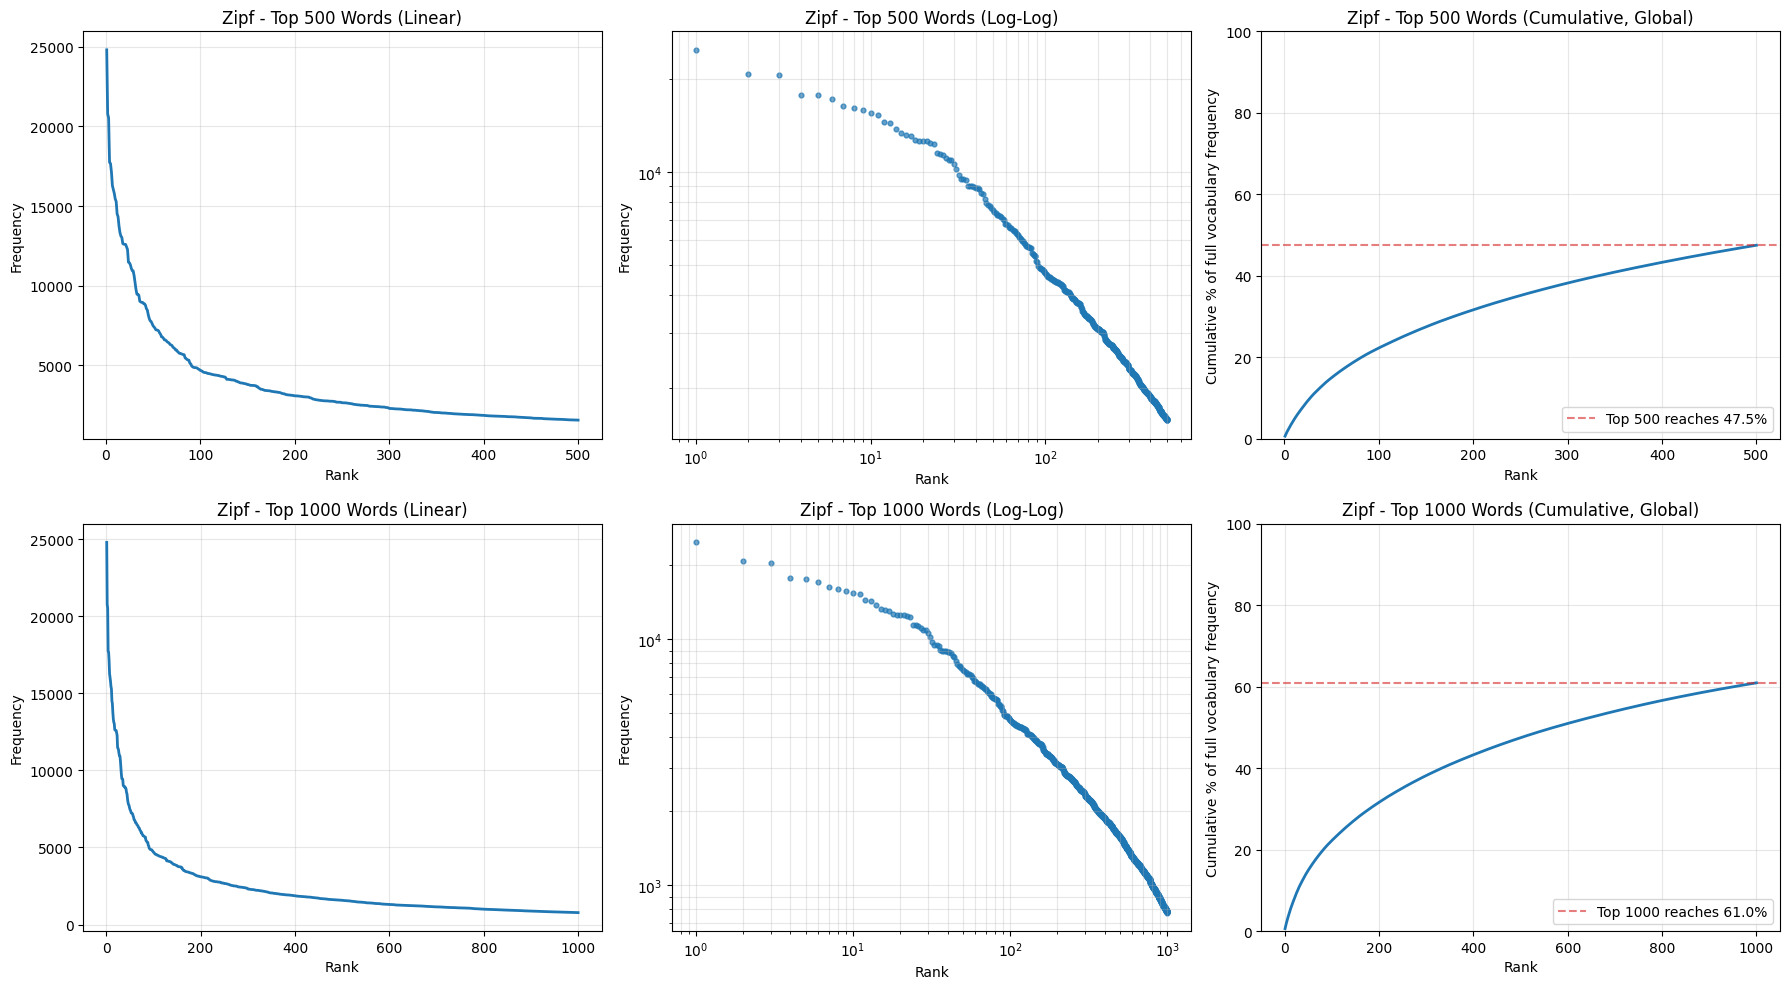

In [8]:
term_freq_counter = Counter()
for doc in campaigns["lemmatized"]:
    # Zipf should use total token frequency, not document presence.
    term_freq_counter.update(doc)

zipf_df = pd.DataFrame({
    'word': list(term_freq_counter.keys()),
    'frequency': list(term_freq_counter.values())
}).sort_values('frequency', ascending=False).reset_index(drop=True)

# Add rank (1-indexed) and cumulative percentage on full vocabulary
zipf_df['rank'] = range(1, len(zipf_df) + 1)
zipf_df['cumsum_freq'] = zipf_df['frequency'].cumsum()
zipf_df['cumsum_pct'] = 100 * zipf_df['cumsum_freq'] / zipf_df['frequency'].sum()

print(f"zipf's law demonstration in our dataset:\n {zipf_df}")

# 1) Full vocabulary: frequency (linear + log-log) and cumulative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(zipf_df['rank'], zipf_df['frequency'], alpha=0.6, s=20)
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')
axes[0].set_title("Zipf - Full Vocabulary (Linear)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(zipf_df['rank'], zipf_df['frequency'], alpha=0.6, s=20)
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Frequency')
axes[1].set_title("Zipf - Full Vocabulary (Log-Log)")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, which='both')

axes[2].plot(zipf_df['rank'], zipf_df['cumsum_pct'], linewidth=2)
axes[2].set_xlabel('Rank')
axes[2].set_ylabel('Cumulative % of full vocabulary frequency')
axes[2].set_title("Zipf - Full Vocabulary (Cumulative)")
axes[2].set_ylim(0, 100)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2) Top 500 and Top 2000: frequency (linear + log-log) and cumulative
# Cumulative here is measured against FULL vocabulary total, so curves usually do not reach 100.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_idx, top_n in enumerate([500, 1000]):
    top_df = zipf_df.head(top_n).copy()

    # Global cumulative at rank r (from full vocabulary denominator)
    top_df['global_cumsum_pct'] = top_df['cumsum_pct']
    max_global_pct = top_df['global_cumsum_pct'].iloc[-1]

    # Linear frequency
    axes[row_idx, 0].plot(top_df['rank'], top_df['frequency'], linewidth=2)
    axes[row_idx, 0].set_xlabel('Rank')
    axes[row_idx, 0].set_ylabel('Frequency')
    axes[row_idx, 0].set_title(f"Zipf - Top {top_n} Words (Linear)")
    axes[row_idx, 0].grid(True, alpha=0.3)

    # Log-log frequency
    axes[row_idx, 1].scatter(top_df['rank'], top_df['frequency'], s=12, alpha=0.7)
    axes[row_idx, 1].set_xlabel('Rank')
    axes[row_idx, 1].set_ylabel('Frequency')
    axes[row_idx, 1].set_title(f"Zipf - Top {top_n} Words (Log-Log)")
    axes[row_idx, 1].set_xscale('log')
    axes[row_idx, 1].set_yscale('log')
    axes[row_idx, 1].grid(True, alpha=0.3, which='both')

    # Cumulative against full vocabulary
    axes[row_idx, 2].plot(top_df['rank'], top_df['global_cumsum_pct'], linewidth=2)
    axes[row_idx, 2].axhline(max_global_pct, color='tab:red', linestyle='--', alpha=0.6,
                             label=f"Top {top_n} reaches {max_global_pct:.1f}%")
    axes[row_idx, 2].set_xlabel('Rank')
    axes[row_idx, 2].set_ylabel('Cumulative % of full vocabulary frequency')
    axes[row_idx, 2].set_title(f"Zipf - Top {top_n} Words (Cumulative, Global)")
    axes[row_idx, 2].set_ylim(0, 100)
    axes[row_idx, 2].grid(True, alpha=0.3)
    axes[row_idx, 2].legend(loc='lower right')


plt.tight_layout()
plt.show()

In [9]:
docs = campaigns['lemmatized']
N = len(docs)

df_counter = Counter()

for doc in docs:
    df_counter.update(set(doc))

df_table = pd.DataFrame({
    'word': list(df_counter.keys()),
    'doc_freq': list(df_counter.values())
})

df_table['doc_freq_ratio'] = df_table['doc_freq'] / N
df_table = df_table.sort_values('doc_freq_ratio', ascending=False)



In [10]:
print(f"total number of tokens is: {len(df_table)}")
df_table


total number of tokens is: 85469


,word,doc_freq,doc_freq_ratio
182,make,6160,0.837639
135,one,5328,0.724504
410,time,5291,0.719472
16,help,5247,0.713489
666,work,5200,0.707098
...,...,...,...
85453,amax,1,0.000136
85452,vpr,1,0.000136
85451,96k,1,0.000136
85450,500series,1,0.000136


In [11]:
min_doc_count = 7
min_ratio = min_doc_count / N
top_n_words = 50


top_words_preview = (
    df_table
    .sort_values('doc_freq_ratio', ascending=False)
    .head(top_n_words)
)

print(df_table[df_table['doc_freq_ratio'] <= min_ratio])
top_words_preview




             word  doc_freq  doc_freq_ratio
35737     paragon         7        0.000952
2834          nes         7        0.000952
38139   recharges         7        0.000952
38142  pioneering         7        0.000952
7954    exploring         7        0.000952
...           ...       ...             ...
85453        amax         1        0.000136
85452         vpr         1        0.000136
85451         96k         1        0.000136
85450   500series         1        0.000136
85449        smux         1        0.000136

[68730 rows x 3 columns]


,word,doc_freq,doc_freq_ratio
182,make,6160,0.837639
135,one,5328,0.724504
410,time,5291,0.719472
16,help,5247,0.713489
666,work,5200,0.707098
362,u,5071,0.689557
175,get,4970,0.675823
348,project,4778,0.649714
845,year,4769,0.648491
332,like,4767,0.648219


In [12]:
vocab = set(
    df_table['word']
)
print(f"length of initial vocabulary is {len(vocab)}")

rare_words = set(df_table['word'][df_table['doc_freq_ratio'] <= min_ratio] )


common_words = set(top_words_preview["word"])
vocab = vocab - common_words - rare_words
print(f"there are {len(common_words)} common words")
print(f"there are {len(rare_words)} rare words")
print(f"Removed {len(rare_words) + len(common_words)} words from vocab")
print(f"the vocabulary size now after having took out the general stopwords (not category specific) is {len(vocab)} tokens")
vocab

length of initial vocabulary is 85469
there are 50 common words
there are 68730 rare words
Removed 68780 words from vocab
the vocabulary size now after having took out the general stopwords (not category specific) is 16689 tokens


{'materialize',
 'forth',
 'shore',
 'clicker',
 'preparation',
 'insatiable',
 'backlog',
 'grabar',
 'rhythms',
 'low',
 'fiercely',
 'unaffiliated',
 'throughout',
 'microwave',
 'belonging',
 'performer',
 'walsh',
 'sweat',
 'stockpile',
 'prevalence',
 'goldstein',
 'hudson',
 'elijah',
 'man',
 'practical',
 'seismic',
 'wrongly',
 'waterproof',
 'infinite',
 'zodiac',
 'spoil',
 'beauty',
 'formative',
 'august',
 'dominated',
 'portrait',
 'expands',
 'southwestern',
 'career',
 'expert',
 'lie',
 'lucid',
 'idyllic',
 'pest',
 'peel',
 'radio',
 'diy',
 'claude',
 'jensen',
 'sweetheart',
 'counteract',
 'twisted',
 'tragically',
 'powell',
 'chamber',
 'olsen',
 'tinkerer',
 'dialect',
 'freeze',
 'burnout',
 'penchant',
 'multitude',
 'hdmi',
 'fists',
 'ali',
 'fleshed',
 'troubled',
 'blizzard',
 'package',
 'brainchild',
 'finalise',
 'coworker',
 'despair',
 'emulator',
 'freshly',
 'mind',
 'democratic',
 'gardner',
 'cleverly',
 'primera',
 'conner',
 'perk',
 'edward

In [13]:
# to actually take the overall common words out CAREFUL TO RUN 
campaigns['description_processed'] = campaigns['lemmatized'].apply(
    lambda doc: [w for w in doc if w in vocab]
)
campaigns = campaigns.drop(columns=['lemmatized'])

In [14]:
df = campaigns

In [15]:
selected_categories = ['Technology', 'Games', 'Music', 'Publishing', 'Film & Video']
cutoff = 0.5
category_high_freq_words = {}

for category_name in selected_categories:
    category_df = df[df["category"] == category_name].copy()
    docs = category_df["description_processed"]
    
    category_counter = Counter()
    for doc in docs:
        category_counter.update(set(doc))

    category_table = pd.DataFrame({
        "word": list(category_counter.keys()),
        "doc_freq": list(category_counter.values())
    })

    category_table["doc_freq_ratio"] = category_table["doc_freq"] / len(docs)
    high_freq_words = category_table[category_table['doc_freq_ratio'] >= cutoff]

    category_high_freq_words[category_name] = high_freq_words
    print(f"\n{category_name}")
    display(high_freq_words)

category_high_freq_words


Technology


,word,doc_freq,doc_freq_ratio
173,build,921,0.618536
182,provide,746,0.501007
255,without,750,0.503694
291,product,854,0.573539
324,allow,823,0.552720



Games


,word,doc_freq,doc_freq_ratio
90,game,1215,0.854430
156,build,777,0.546414
342,add,880,0.618847
446,ship,717,0.504219
455,set,830,0.583685
534,keep,719,0.505626
634,reward,789,0.554852
808,team,737,0.518284
854,base,770,0.541491
1079,player,873,0.613924



Music


...


Publishing


,word,doc_freq,doc_freq_ratio
85,write,722,0.594728
117,book,949,0.781713
743,print,688,0.566722
776,page,612,0.504119



Film & Video


,word,doc_freq,doc_freq_ratio
38,director,1093,0.543511
247,short,1013,0.503729
321,show,1072,0.533068
329,film,1737,0.863749
346,team,1034,0.514172


{'Technology':         word  doc_freq  doc_freq_ratio
 173    build       921        0.618536
 182  provide       746        0.501007
 255  without       750        0.503694
 291  product       854        0.573539
 324    allow       823        0.552720,
 'Games':         word  doc_freq  doc_freq_ratio
 90      game      1215        0.854430
 156    build       777        0.546414
 342      add       880        0.618847
 446     ship       717        0.504219
 455      set       830        0.583685
 534     keep       719        0.505626
 634   reward       789        0.554852
 808     team       737        0.518284
 854     base       770        0.541491
 1079  player       873        0.613924
 1131    full       723        0.508439,
 'Music':          word  doc_freq  doc_freq_ratio
 45     record      1010        0.829228
 99   musician       631        0.518062
 116      live       609        0.500000
 122      song       883        0.724959
 163     music      1068        0.876847


In [16]:
category_stopwords_all = set()

for category_name, high_freq_words in category_high_freq_words.items():
    category_words = high_freq_words["word"].tolist()
    category_stopwords_all.update(category_words)
    print(f"\n{category_name} ({len(category_words)} words)")
    print(category_words)

print(f"\nTotal unique category stopwords: {len(category_stopwords_all)}")
category_stopwords_all


Technology (5 words)
['build', 'provide', 'without', 'product', 'allow']

Games (11 words)
['game', 'build', 'add', 'ship', 'set', 'keep', 'reward', 'team', 'base', 'player', 'full']

Music (10 words)
['record', 'musician', 'live', 'song', 'music', 'studio', 'album', 'thank', 'write', 'release']

Publishing (4 words)
['write', 'book', 'print', 'page']

Film & Video (5 words)
['director', 'short', 'show', 'film', 'team']

Total unique category stopwords: 32


{'add',
 'album',
 'allow',
 'base',
 'book',
 'build',
 'director',
 'film',
 'full',
 'game',
 'keep',
 'live',
 'music',
 'musician',
 'page',
 'player',
 'print',
 'product',
 'provide',
 'record',
 'release',
 'reward',
 'set',
 'ship',
 'short',
 'show',
 'song',
 'studio',
 'team',
 'thank',
 'without',
 'write'}

In [17]:
vocab = vocab - category_stopwords_all
print(f"final vocabulary length: {len(vocab)}")
df["description_processed"] = df["description_processed"].apply(
    lambda doc: [word for word in doc if word in vocab]
)

final vocabulary length: 16657


In [18]:
print(f"final vocabulary length: {len(vocab)}")
df["description_processed"] = df["description_processed"].apply(
    lambda doc: [word for word in doc if word in vocab]
)

final vocabulary length: 16657


In [19]:
df['pos_tagged'] = df['description_processed'].apply(nltk.pos_tag)


In [20]:
# only at the end 
df.to_csv('Kickstarter_processed.csv')